In [2]:
import pandas as pd
import numpy as np


pd.set_option('display.max_colwidth', None)
np.random.seed(45)

# Toggle between RETFound embeddings and FID (Inception v3) embeddings
USE_FID = True

suffix = 'fid' if USE_FID else 'latents'
n_feats = 2048 if USE_FID else 1024

real_out = pd.concat([pd.read_csv('/data/7TB/nick/ai_readi_v3/resized_retinal_photography/{}_{}.csv'.format(x, suffix), index_col=0) for x in ['val', 'test']])
real_out_vals = real_out.values[:, -n_feats:].astype(np.float32)

real_train = pd.read_csv('/data/7TB/nick/ai_readi_v3/resized_retinal_photography/train_{}.csv'.format(suffix), index_col=0)
IDs = np.random.choice(real_train['person_id'].unique(), size=real_out['person_id'].unique().shape[0], replace=False)
real_train = real_train[real_train['person_id'].apply(lambda x: x in IDs)]
real_train_vals = real_train.values[:, -n_feats:].astype(np.float32)

synthetic = pd.concat([pd.read_csv('/data/7TB/nick/synth_ai_readi_fundus/retinal_photography/{}_{}.csv'.format(x, suffix), index_col=0) for x in ['train', 'val', 'test']])
synthetic_vals = synthetic.values[:, -n_feats:].astype(np.float32)

In [3]:
from tqdm import tqdm

mins = []
means = []
true = []
path = []
for i in tqdm(range(len(real_train_vals))):
    dist = np.linalg.norm(synthetic_vals - real_train_vals[i], axis=1)
    mins.append(dist.min())
    means.append(dist.mean())
    true.append(1)
    path.append(real_train.iloc[i]['filepath'])

for i in tqdm(range(len(real_out_vals))):
    dist = np.linalg.norm(synthetic_vals - real_out_vals[i], axis=1)
    mins.append(dist.min())
    means.append(dist.mean())
    true.append(0)
    path.append(real_out.iloc[i]['filepath'])

df = pd.DataFrame({'min_dist':mins, 'mean_dist':means, 'true':true, 'path':path})

100%|██████████| 28933/28933 [1:22:06<00:00,  5.87it/s]


In [4]:
#plt.hist(np.linalg.norm(synthetic_vals - real_train_vals[i], axis=1), alpha=0.5)
#plt.hist(np.linalg.norm(synthetic_vals - real_out_vals[i], axis=1), alpha=0.5)

In [5]:
df.to_csv('min_distance_fundus.csv')

# Read in similarity measures
#df = pd.read_csv('min_distance_fundus.csv', index_col=0)

## Threat Model
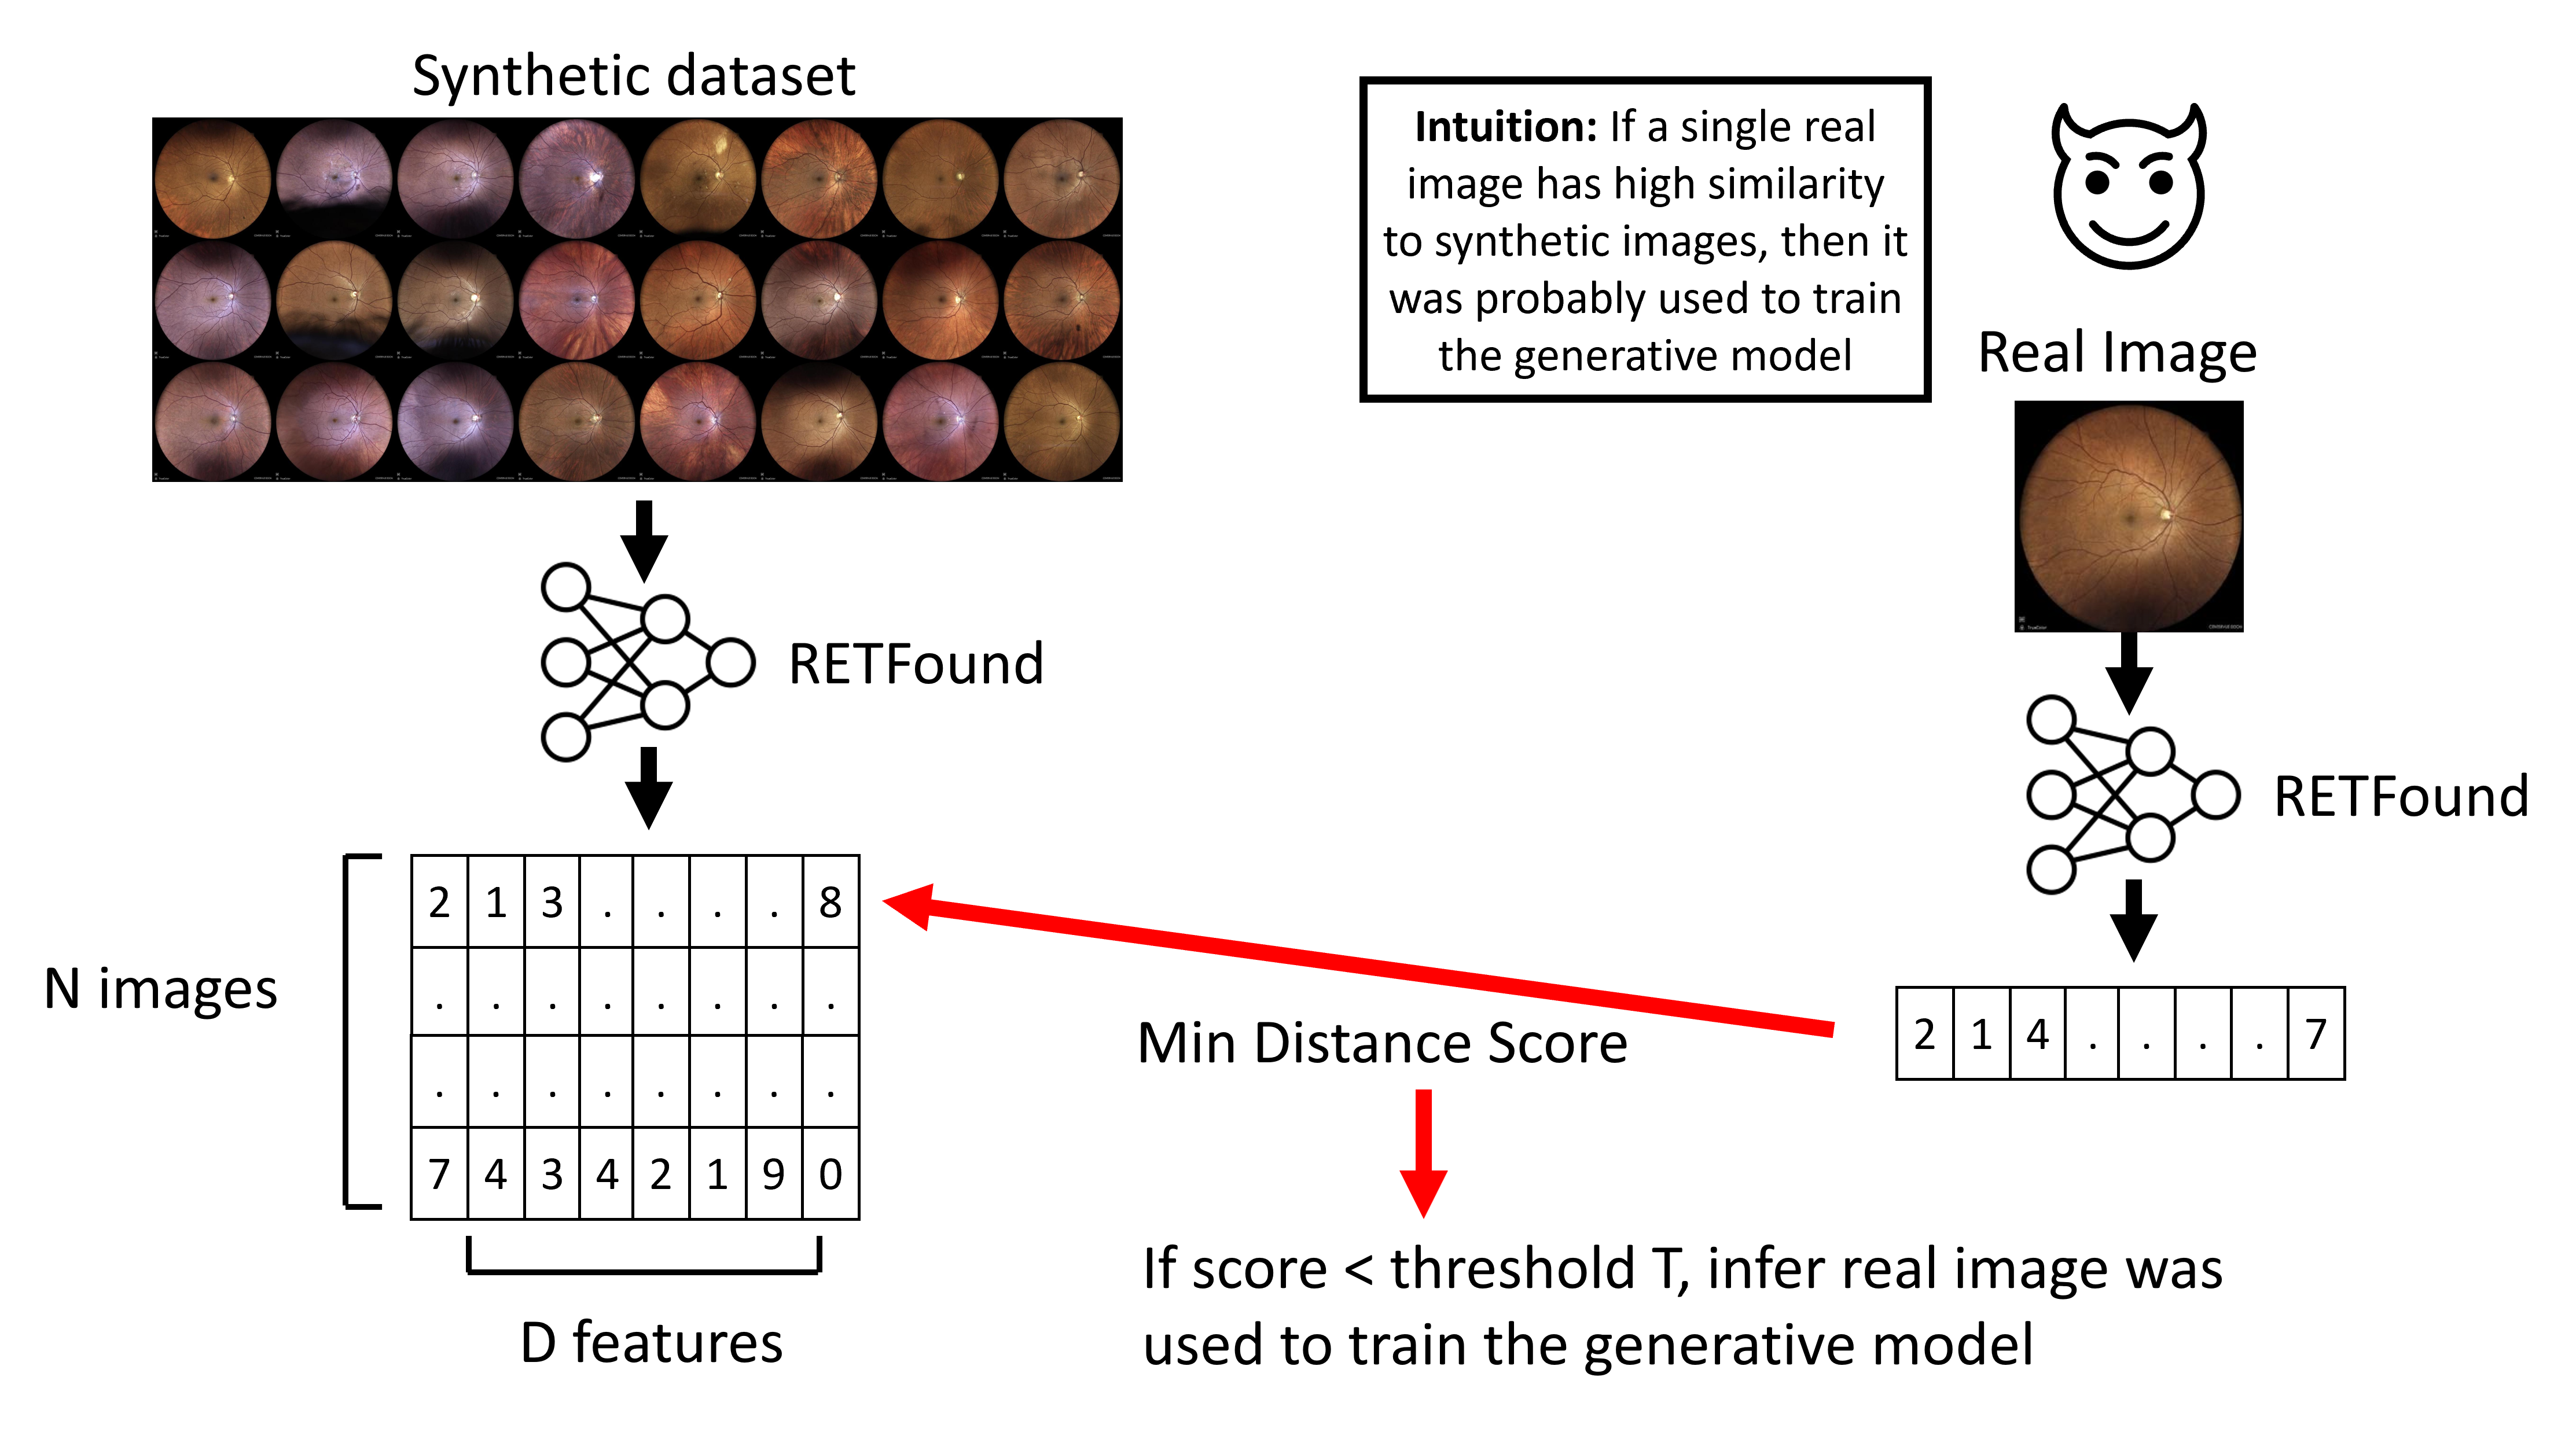

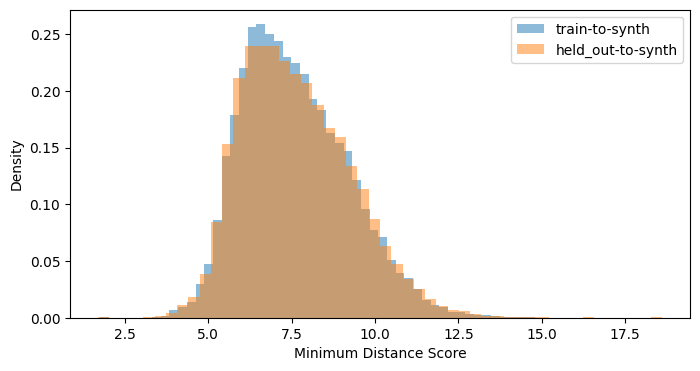

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.hist(df['min_dist'].values[df['true'] == 1], density=True, alpha=0.5, label='train-to-synth', bins=50)
plt.hist(df['min_dist'].values[df['true'] == 0], density=True, alpha=0.5, label='held_out-to-synth', bins=50)
#plt.hist(df['min_dist'].values[df['true'] == 2], density=True, alpha=0.5, label='val-synth', bins=100)
#plt.hist(df['min_dist'].values[df['true'] == 3], density=True, alpha=0.5, label='test-synth', bins=100)
plt.xlabel('Minimum Distance Score')
plt.ylabel("Density")
plt.legend()
plt.show()



In [7]:
df = df[df['true'] <= 1]

Sens = []
Spec = []
Prec = []
t = []
F1 = []
Acc = []
from sklearn.metrics import f1_score, accuracy_score, recall_score, confusion_matrix, precision_score

for threshold in np.linspace(0.0, df['min_dist'].max()*1.1, 1_000):
    df['pred'] = (df['min_dist'] < threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(df['true'], df['pred']).ravel()
    spec = tn / (tn + fp)
    sens = recall_score(df['true'], df['pred'])
    prec = precision_score(df['true'], df['pred'])
    acc = accuracy_score(df['true'], df['pred'])

    Sens.append(sens)
    Spec.append(spec)
    Prec.append(prec)
    t.append(threshold)
    F1.append(f1_score(df['true'], df['pred']))
    Acc.append(acc)

Sens = np.array(Sens)
Spec = np.array(Spec)
Prec = np.array(Prec)
t = np.array(t)
F1 = np.array(F1)
Acc = np.array(Acc)


/home/nick/.conda/envs/ai_readi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/nick/.conda/envs/ai_readi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/nick/.conda/envs/ai_readi/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/nick

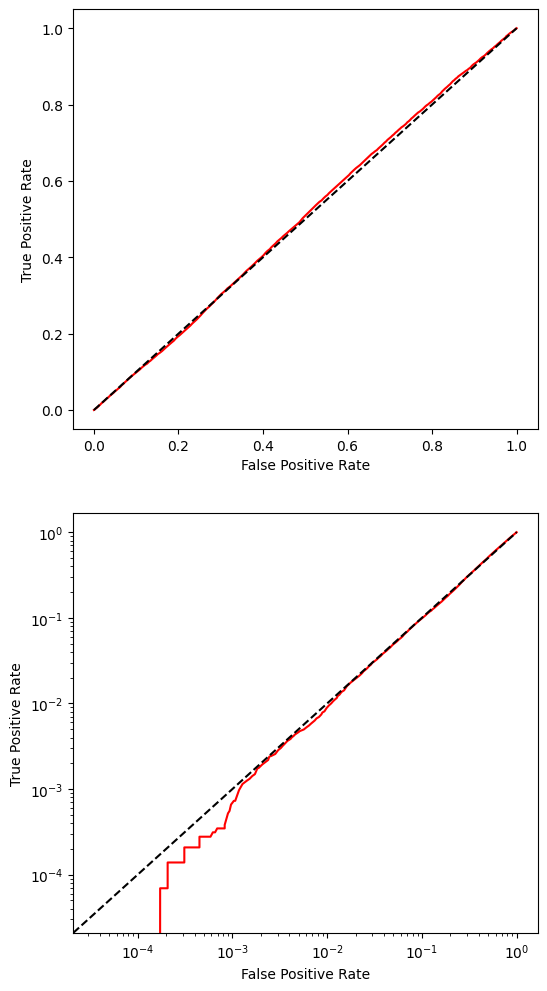

AUC: 0.49509845121298157


In [8]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(6,12))
plt.subplot(2,1,1)
plt.plot(1-Spec, Sens, color='red')
plt.plot([0, 1], [0,1], color='black', linestyle='--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.subplot(2,1,2)
plt.plot(1-Spec, Sens, color='red')
plt.plot([0, 1], [0,1], color='black', linestyle='--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.xscale('log')
plt.yscale('log')
plt.show()
from sklearn.metrics import auc
print("AUC:", auc(Sens, 1-Spec))

In [9]:
thresholds = [0.1, 0.5, 1, 2, 3, 4]

inds = []
for thresh in thresholds:
    inds.append(int(np.argmax(t>thresh)))


res = pd.DataFrame({"Threshold": thresholds,
                    'Precision': Prec[inds],
                    'Recall': Sens[inds],
                    'Specificity': Spec[inds],
                    'F1': F1[inds],
                    "Accuracy": Acc[inds]})
res

,Threshold,Precision,Recall,Specificity,F1,Accuracy
0,0.1,0.000000,0.000000,1.000000,0.000000,0.501056
1,0.5,0.000000,0.000000,1.000000,0.000000,0.501056
2,1.0,0.000000,0.000000,1.000000,0.000000,0.501056
3,2.0,0.285714,0.000069,0.999827,0.000139,0.501004
4,3.0,0.400000,0.000139,0.999793,0.000278,0.501022
5,4.0,0.481132,0.001770,0.998099,0.003527,0.500987
